# 06. The BSTS against LightGBM

The two strongest forecasters in this study win on different things, and
neither dominates, so this notebook lays the trade-off out in full. Where does
LightGBM win (marginal accuracy, operational simplicity), where does the BSTS
win (short-lead sharpness, coherent scenarios, a full density, a decomposed
account of its own uncertainty), what does each cost, and is the richer BSTS
output paid for in calibration? Every claim is shown on the test set.

One structural fact sits underneath every difference. LightGBM's forecast is
fifteen independent per-step quantile heads: marginal numbers with no joint law
and no density between or beyond the quantile levels. The BSTS forecast is a
set of jointly sampled paths drawn from a generative model. That single
distinction is why the wins fall where they do.

Throughout, the BSTS forecaster is the NUTS reference posterior (BSTS-NUTS);
notebook 04 is where the variational fit is checked against it.

In [1]:
import warnings

warnings.filterwarnings("ignore", message="IProgress not found")  # quiet the tqdm widget notice

import os

os.environ.setdefault("JAX_PLATFORMS", "cpu")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from nemforecastdemand.config import load_config
from nemforecastdemand.data.loaders import load_panel, load_splits
from nemforecastdemand.evaluation.calibration import (
    averaged_gaussian_cdf,
    averaged_gaussian_pdf,
    ecdf_uniform_band,
    pit_ecdf_difference,
    pit_histogram,
    rb_pit,
)
from nemforecastdemand.evaluation.metrics import (
    crps_from_quantiles,
    crps_samples,
    energy_score,
    rb_log_score,
)
from nemforecastdemand.models import bsts, innovations
from nemforecastdemand.models.base import build_design, variance_design
from nemforecastdemand.models.predict import variance_decomposition_innovations
from nemforecastdemand.plotting import (
    MODEL_COLOURS,
    density_ribbon,
    model_shades,
    pass_fail_diagonal,
    pass_fail_hband,
    save_figure,
    sequential_cmap,
    setup_style,
)
from nemforecastdemand.splits import horizon_index, rolling_origins
from nemforecastdemand.utils import load_artifact

setup_style()
cfg = load_config()

# NUTS is the BSTS forecaster throughout this notebook; notebook 04 covers the
# variational-against-NUTS comparison.
ar_nuts, ar_meta = load_artifact(cfg.paths.artifacts / "bsts_innovations_nuts_warm_fullrank_w300")
gbdt, gbdt_meta = load_artifact(cfg.paths.artifacts / "gbdt")
levels = np.array(gbdt_meta["quantile_levels"])

paths = ar_nuts["forecast_paths"]  # (S, O, H) coherent posterior predictive paths (NUTS)
bsts_mean = ar_nuts["forecast_path_mean"]  # (S, O, H) per-draw predictive mean, MW
bsts_sd = ar_nuts["forecast_path_sd"]  # (S, O, H) per-draw predictive sd, MW
quantiles = gbdt["forecast_quantiles"]  # (O, Q, H) per-step marginal quantiles
lg_median = quantiles[:, levels.tolist().index(0.5), :]  # the pinball-0.5 point forecast
lg_mean = gbdt["forecast_mean"]  # the separately trained L2 mean head
y = ar_nuts["y_test"]
n_draws, n_origins, horizon = paths.shape
hours = (np.arange(horizon) + 1) / 2
BSTS_C, LG_GREEN = MODEL_COLOURS["BSTS-NUTS"], MODEL_COLOURS["LightGBM"]
BSTS_CMAP = sequential_cmap(BSTS_C)  # the BSTS predictive density field rides its model colour

# NUTS posterior draws of the AR sites, flattened over chains and thinned, for
# the variance decomposition and the any-origin recursive forecast.
AR_SITES = ("phi1", "phi2", "beta", "gamma0", "gamma")
nuts_flat = {
    name: ar_nuts[f"post_{name}"].reshape(-1, *ar_nuts[f"post_{name}"].shape[2:]) for name in AR_SITES
}
thin = max(nuts_flat["phi1"].shape[0] // 1000, 1)
nuts_draws = {name: value[::thin] for name, value in nuts_flat.items()}

bayes_origin_crps = np.array([crps_samples(y[i], paths[:, i, :]).mean() for i in range(n_origins)])
lg_origin_crps = np.array(
    [crps_from_quantiles(y[i], quantiles[i], levels).mean() for i in range(n_origins)]
)
bayes_h = np.array([crps_samples(y[:, h], paths[:, :, h]).mean() for h in range(horizon)])
lg_h = np.stack([crps_from_quantiles(y[i], quantiles[i], levels) for i in range(n_origins)]).mean(
    axis=0
)

origin_times = (
    pd.DatetimeIndex(ar_nuts["origins_test"].astype("datetime64[us]"))
    .tz_localize("UTC")
    .tz_convert("Australia/Brisbane")
)
daily_mean = y.mean(axis=1)
typical = int(np.argsort(bayes_origin_crps)[n_origins // 2])  # median-difficulty day
# Three days spanning the demand range, chosen among the better-forecast days
# (CRPS in the lower 60%) so the examples show representative BSTS behaviour
# rather than its worst, then split low/median/high by daily mean demand.
crps_rank = bayes_origin_crps.argsort().argsort()
well_forecast = np.where(crps_rank < int(0.6 * n_origins))[0]
by_demand = well_forecast[np.argsort(daily_mean[well_forecast])]
examples = {
    "low-demand day": int(by_demand[int(0.15 * len(by_demand))]),
    "median-demand day": int(by_demand[len(by_demand) // 2]),
    "high-demand day": int(by_demand[int(0.85 * len(by_demand))]),
}


idx = np.arange(horizon)

## The headline trade

LightGBM has the lower CRPS overall, but a per-lead-time view shows the two
owning different parts of the horizon: the BSTS is much sharper in the first
hours, and LightGBM pulls ahead once the lead grows.

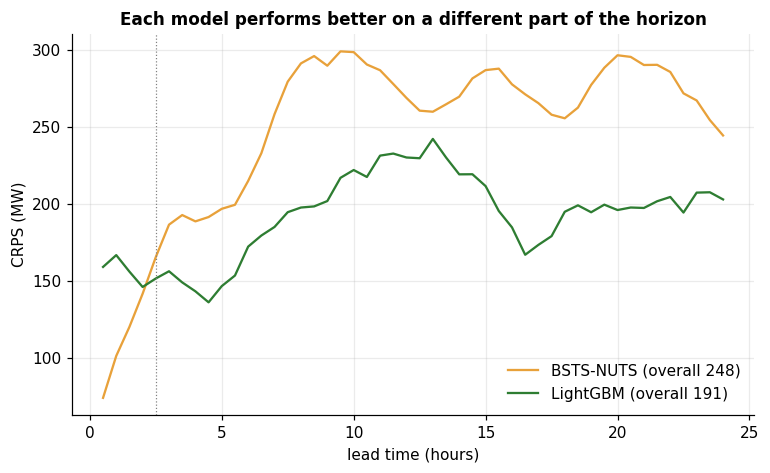

In [2]:
crossover = next((h + 1 for h in range(horizon) if bayes_h[h] > lg_h[h]), None)
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(hours, bayes_h, color=BSTS_C, label=f"BSTS-NUTS (overall {bayes_origin_crps.mean():.0f})")
ax.plot(hours, lg_h, color=LG_GREEN, label=f"LightGBM (overall {lg_origin_crps.mean():.0f})")
if crossover:
    ax.axvline(crossover / 2, color="grey", ls=":", lw=0.8)
ax.set_xlabel("lead time (hours)")
ax.set_ylabel("CRPS (MW)")
ax.set_title("Each model performs better on a different part of the horizon")
ax.legend()
save_figure(fig, "bench_horizon_crps", cfg.paths.figures)
plt.show()

*Takeaway: the BSTS is more than twice as sharp at the first half hour; the curves cross a few hours out, after which LightGBM is the sharper.*

## Forecasts, and which point summary to read off them

The natural way to show a probabilistic forecast, with the observed laid over. I
choose the four days below by test-set CRPS to keep it fair: one both forecast
well, one both find hard, and the two where they disagree most. The left column
draws the BSTS as a density field (the Rao-Blackwellised mixture, deepest where
the predictive is densest) with its 50 and 90 percent intervals as dotted lines;
the right shows all LightGBM can offer, the same two intervals as dotted lines
from its quantile heads with no density to fill between them. That contrast,
a density against a handful of quantiles, is the structural difference the rest
of the notebook turns on.

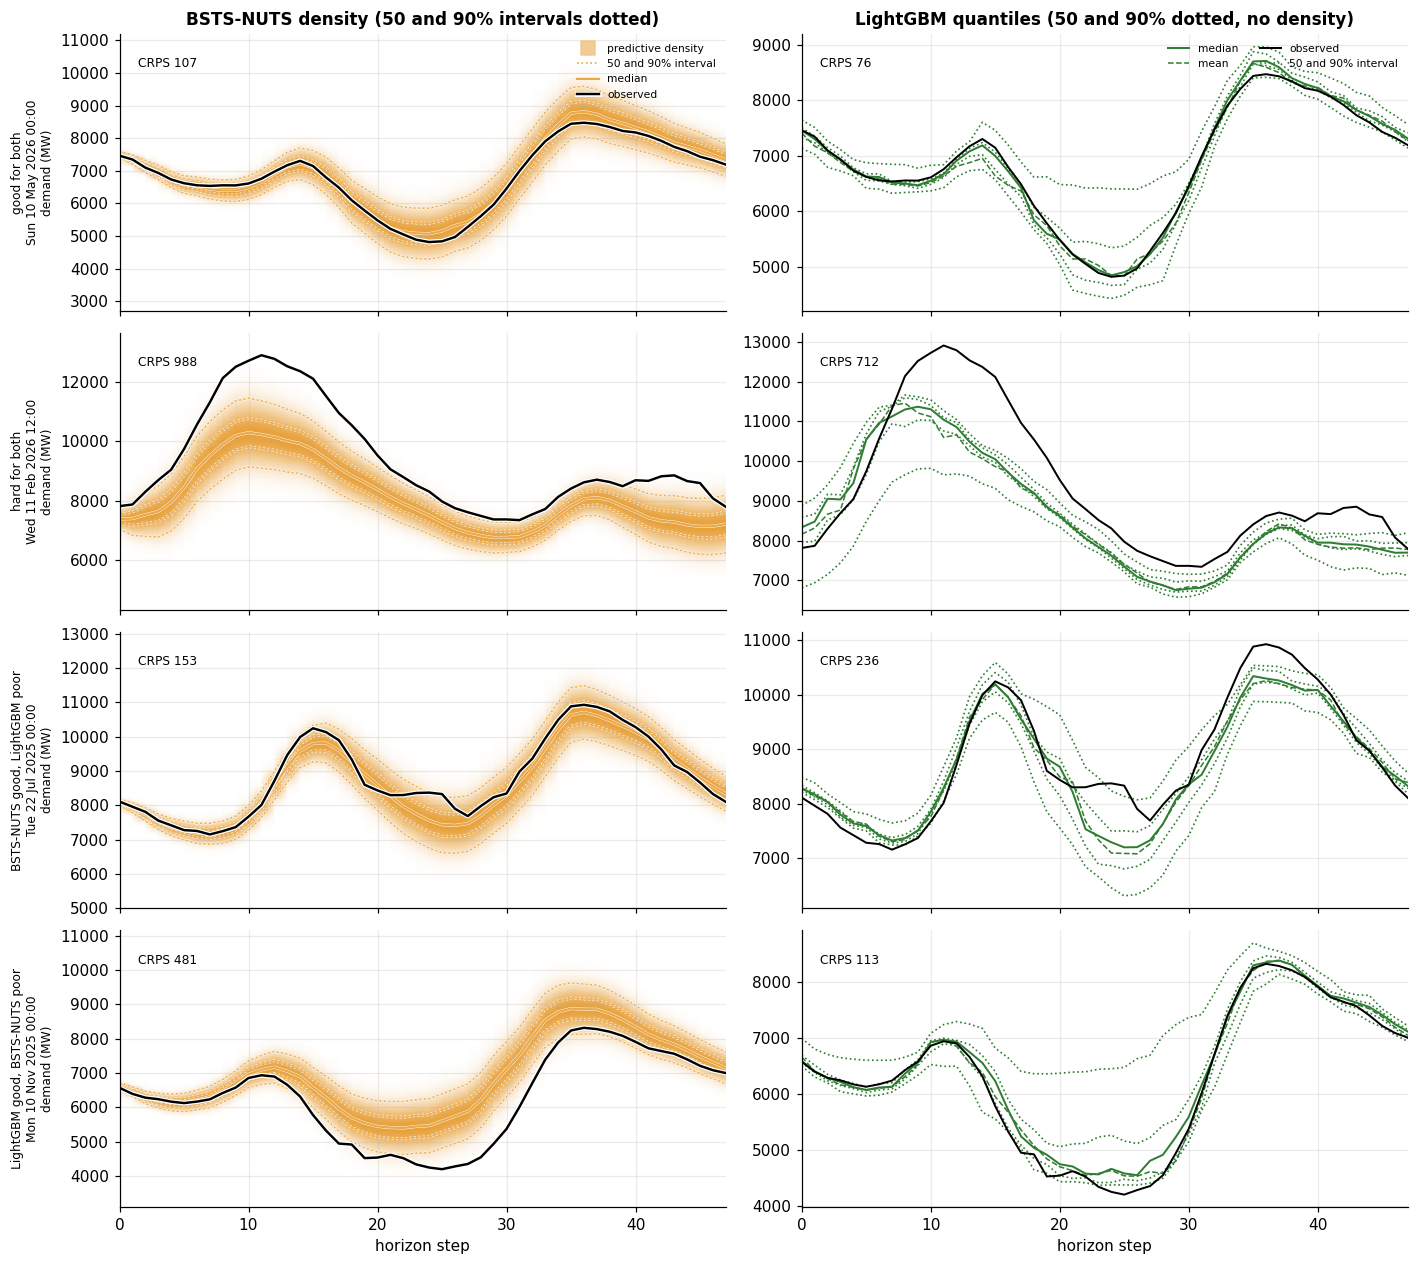

In [3]:
gr = bayes_origin_crps.argsort().argsort()  # 0 = best-scored test day
lr = lg_origin_crps.argsort().argsort()
fan_days = {
    "good for both": int((gr + lr).argmin()),
    "hard for both": int((gr + lr).argmax()),
    "BSTS-NUTS good, LightGBM poor": int((lr - gr).argmax()),
    "LightGBM good, BSTS-NUTS poor": int((gr - lr).argmax()),
}
lg_bands = [(0.05, 0.95), (0.25, 0.75)]  # the two intervals LightGBM can draw from its quantiles

fig, axes = plt.subplots(len(fan_days), 2, figsize=(13, 2.9 * len(fan_days)), sharex=True)
for row, (label, i) in enumerate(fan_days.items()):
    date = origin_times[i].strftime("%a %d %b %Y %H:%M")
    density_ribbon(
        axes[row, 0],
        idx,
        draw_mean=bsts_mean[:, i, :],
        draw_sd=bsts_sd[:, i, :],
        observed=y[i],
        cmap=BSTS_CMAP,
        label="median",
    )
    axes[row, 0].set_ylabel(f"{label}\n{date}\ndemand (MW)", fontsize=8)
    axes[row, 0].annotate(
        f"CRPS {bayes_origin_crps[i]:.0f}", (0.03, 0.88), xycoords="axes fraction", fontsize=8
    )
    for lo, hi in lg_bands:
        axes[row, 1].plot(idx, quantiles[i, levels.tolist().index(lo), :], ls=":", lw=1.1, color=LG_GREEN)
        axes[row, 1].plot(idx, quantiles[i, levels.tolist().index(hi), :], ls=":", lw=1.1, color=LG_GREEN)
    axes[row, 1].plot(
        idx, quantiles[i, levels.tolist().index(0.5), :], color=LG_GREEN, lw=1.3, label="median"
    )
    axes[row, 1].plot(idx, lg_mean[i], color=LG_GREEN, lw=1.0, ls="--", label="mean")
    axes[row, 1].plot(idx, y[i], color="black", lw=1.3, label="observed")
    axes[row, 1].annotate(
        f"CRPS {lg_origin_crps[i]:.0f}", (0.03, 0.88), xycoords="axes fraction", fontsize=8
    )
# name the LightGBM dotted lines in its legend
axes[0, 1].plot([], [], ls=":", lw=1.1, color=LG_GREEN, label="50 and 90% interval")
axes[0, 0].set_title("BSTS-NUTS density (50 and 90% intervals dotted)")
axes[0, 1].set_title("LightGBM quantiles (50 and 90% dotted, no density)")
axes[0, 0].legend(fontsize=7, loc="upper right")
axes[0, 1].legend(fontsize=7, ncol=2, loc="upper right")
axes[-1, 0].set_xlabel("horizon step")
axes[-1, 1].set_xlabel("horizon step")
fig.tight_layout()
save_figure(fig, "bench_fan_charts", cfg.paths.figures)
plt.show()

*Takeaway: on the disagreement days each model in turn fits the shape the other misses; the BSTS shows a filled density between its dotted intervals where LightGBM has only the dotted quantile lines, and LightGBM's mean and median separate on the peaks where the BSTS density stays near-symmetric.*

That separation raises a natural question: does it matter whether the point
forecast is the mean or the median, and does the answer depend on the model or
on how it was fitted? The median minimises expected absolute error and the mean
expected squared error, so the two only part company when the predictive is
skewed. The table sets MAE and RMSE from each summary, for the BSTS and for
LightGBM with its median head beside its separately trained mean head.

In [4]:
def _mae(a):
    return float(np.abs(a - y).mean())


def _rmse(a):
    return float(np.sqrt(((a - y) ** 2).mean()))


def _summary(point_mean, point_median):
    return {
        "MAE mean": _mae(point_mean),
        "MAE median": _mae(point_median),
        "RMSE mean": _rmse(point_mean),
        "RMSE median": _rmse(point_median),
    }


point_summary = pd.DataFrame(
    {
        "BSTS-NUTS": _summary(paths.mean(0), np.median(paths, 0)),
        "LightGBM": _summary(lg_mean, lg_median),
    }
).T[["MAE mean", "MAE median", "RMSE mean", "RMSE median"]]
point_summary.round(1)

,MAE mean,MAE median,RMSE mean,RMSE median
BSTS-NUTS,337.5,337.8,505.7,506.0
LightGBM,262.4,254.3,385.2,370.8


*Takeaway: for the BSTS the mean and median sit on top of each other (the posterior is near-Gaussian); LightGBM's median beats its separately trained mean head, dragged up by the heavy right tail at the peaks. For a skewed target the median is the safer point forecast, and one coherent predictive gives both off a single object.*

## Where LightGBM wins

### Marginal accuracy, and it learns its interactions without help

On the headline number LightGBM is clearly better: lower CRPS, lower point
error, and the win widens with lead time. Both models see the same design, but
the BSTS needs hand-built features to get this close (a temperature spline,
thermal-inertia degree days, and degree-day-by-time interactions), whereas the
trees learn whatever non-linearities and interactions matter directly from the
data. Once the AR anchor has decayed, that flexible non-linear mean is what
carries LightGBM ahead.

In [5]:
bayes_med = paths.mean(axis=0)
lg_med = quantiles[:, levels.tolist().index(0.5), :]
pd.DataFrame(
    {
        "BSTS-NUTS": {
            "CRPS (MW)": bayes_origin_crps.mean(),
            "MAE (MW)": float(np.abs(bayes_med - y).mean()),
            "CRPS at 30 min (MW)": bayes_h[0],
            "CRPS at 24 h (MW)": bayes_h[47],
        },
        "LightGBM": {
            "CRPS (MW)": lg_origin_crps.mean(),
            "MAE (MW)": float(np.abs(lg_med - y).mean()),
            "CRPS at 30 min (MW)": lg_h[0],
            "CRPS at 24 h (MW)": lg_h[47],
        },
    }
).round(0)

,BSTS-NUTS,LightGBM
CRPS (MW),248.0,191.0
MAE (MW),338.0,254.0
CRPS at 30 min (MW),74.0,159.0
CRPS at 24 h (MW),244.0,203.0


*Takeaway: LightGBM wins overall CRPS and the 24-hour lead; the BSTS wins decisively at 30 minutes.*

### Operational simplicity: nothing to babysit

This is LightGBM's deeper advantage. It fits deterministically: call it, get
the heads, done. A *head* here is one fitted output of the model, so LightGBM
is fifteen gradient-boosted models, one per quantile level, plus a separate
mean head. The BSTS forecast is the product of an inference apparatus that has
to be watched: cold NUTS lands in degenerate modes (notebook 04), so the model
is reached through a warm-started NUTS reference, which carries the predictions
here. None of R-hat, warm starts, multimodality or approximation adjudication
exists for LightGBM. In production that means fewer ways to fail silently and
less expertise to keep it running.

|                                 | LightGBM | BSTS                       |
| ------------------------------- | -------- | -------------------------- |
| fits deterministically          | yes      | no (stochastic VI/MCMC)    |
| convergence to monitor          | none     | ELBO, R-hat, ESS           |
| multimodality risk              | none     | yes (cold NUTS multimodal) |
| hand-built interactions needed  | no       | yes                        |

*Takeaway: LightGBM has nothing to monitor and no interactions to hand-build, which is its real operational edge.*

### Compute, measured both ways

Speed is not where LightGBM wins, and that is worth stating plainly. On this
machine the BSTS likelihood is vectorised on the GPU while LightGBM trains
fifteen separate quantile heads on the CPU. The warm-started NUTS reference
fits and forecasts end to end in under twenty seconds, comfortably inside
LightGBM's own wall-clock. LightGBM's advantage is operational simplicity, not
run time, and the numbers should make that precise rather than imply a speed
edge it does not have.

In [6]:
ar_fit = ar_meta["timings_seconds"]
compute = pd.DataFrame(
    {
        "LightGBM (15 heads, CPU)": {
            "fit (s)": gbdt_meta["timings_seconds"]["fit"],
            "forecast all origins and variants (s)": gbdt_meta["timings_seconds"]["test_forecasts"],
        },
        "BSTS-NUTS (GPU)": {
            "fit (s)": ar_meta["advi_seconds"] + ar_fit["warmup_seconds"] + ar_fit["sample_seconds"],
            "forecast all origins and variants (s)": ar_meta.get("predict_seconds", float("nan")),
        },
    }
).T
compute.round(1)

,fit (s),forecast all origins and variants (s)
"LightGBM (15 heads, CPU)",35.3,27.7
BSTS-NUTS (GPU),14.8,7.4


*Takeaway: the warm-started NUTS reference fits and forecasts quicker end to end than LightGBM, so LightGBM's win is simplicity, not speed.*

## Where the BSTS wins

### 1. Sharpest at short lead

The crossover figure already gave it away: at the first half hour the BSTS is
more than twice as sharp. The reason is the AR([1,2]) error, which carries the last
two residuals observed at the forecast origin forward through its impulse
response, anchoring the first steps to what just happened. LightGBM sees the
lagged-demand and recency features but never the realised error at issue time,
so it cannot tighten the near horizon the same way.

In [7]:
pd.DataFrame(
    {
        "lead (h)": [0.5, 1, 2, 3, 6],
        "BSTS-NUTS CRPS": [bayes_h[i] for i in (0, 1, 3, 5, 11)],
        "LightGBM CRPS": [lg_h[i] for i in (0, 1, 3, 5, 11)],
    }
).set_index("lead (h)").round(0)

,BSTS-NUTS CRPS,LightGBM CRPS
lead (h),,
0.5,74.0,159.0
1.0,101.0,167.0
2.0,141.0,146.0
3.0,186.0,156.0
6.0,215.0,172.0


*Takeaway: the BSTS halves LightGBM's CRPS in the first half hour, and the gap closes by a few hours out.*

### 2. Coherent scenarios, the generative payoff

The BSTS is generative: each posterior draw is a full distribution over the whole
day, so any function of the 48 steps has a correct distribution. LightGBM's
marginal heads give only per-step quantile bands. The three rows below span the
demand range; the left panel is the BSTS predictive density (Rao-Blackwellised
over the draws) against the observed, the right LightGBM's per-step quantile fan.
Both track the observed, but the BSTS carries a full density where LightGBM
carries bands, and that density is built from coherent whole-day paths, which the
rest of this section measures and draws.

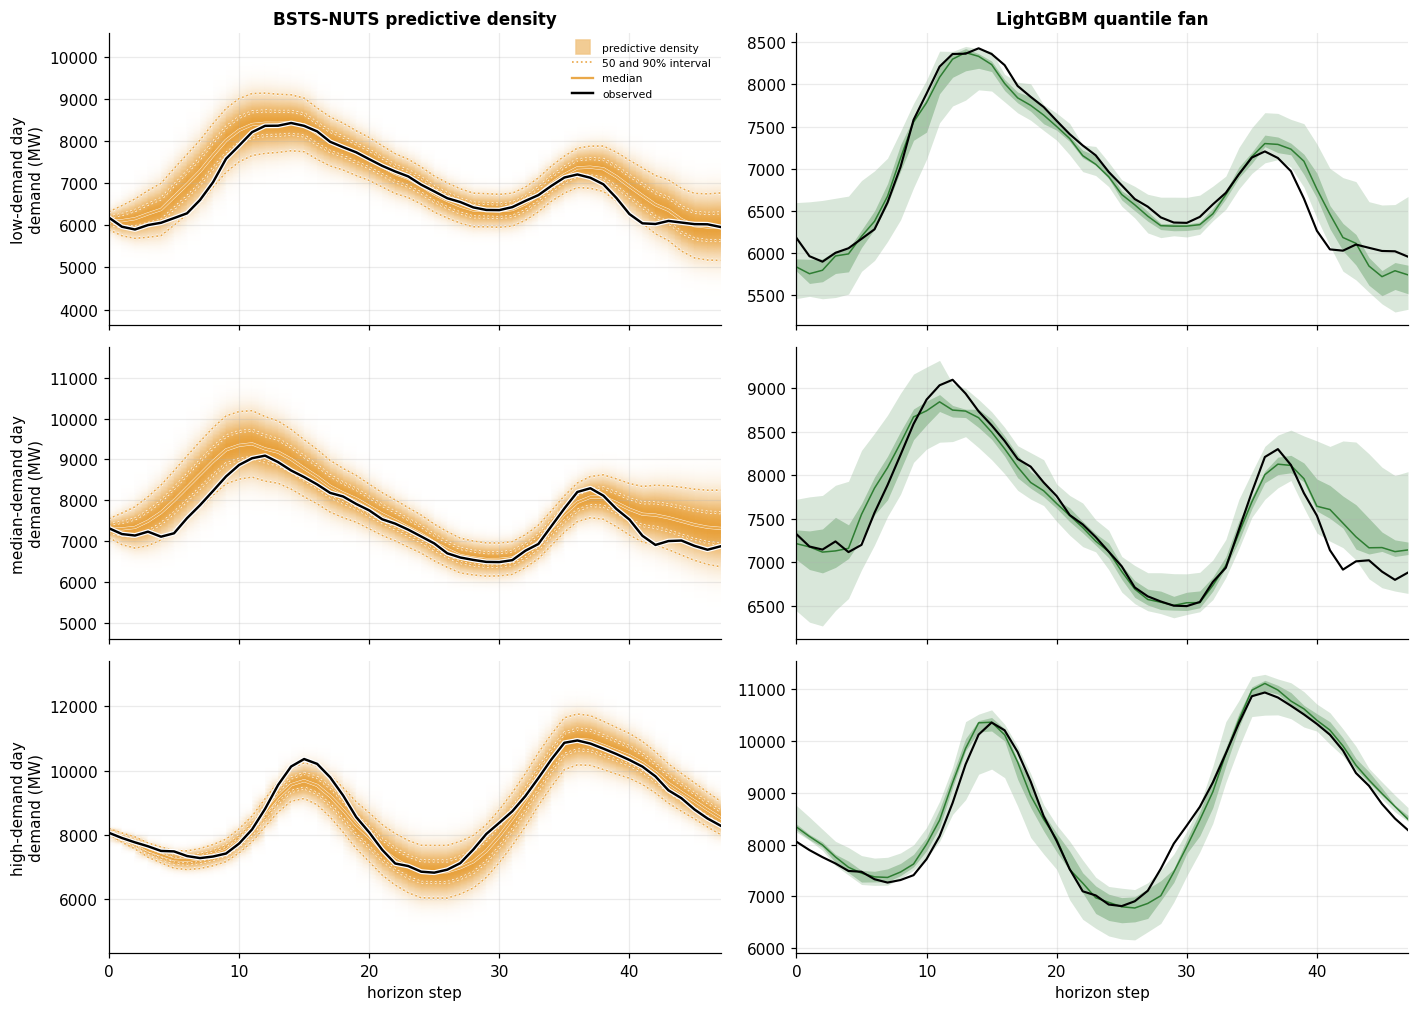

In [8]:
fig, axes = plt.subplots(len(examples), 2, figsize=(13, 3.1 * len(examples)), sharex=True)
for row, (label, i) in enumerate(examples.items()):
    density_ribbon(
        axes[row, 0],
        idx,
        draw_mean=bsts_mean[:, i, :],
        draw_sd=bsts_sd[:, i, :],
        observed=y[i],
        cmap=BSTS_CMAP,
        label="median",
    )
    axes[row, 0].set_ylabel(f"{label}\ndemand (MW)")
    for lo, hi, a in [(0.05, 0.95, 0.18), (0.25, 0.75, 0.30)]:
        axes[row, 1].fill_between(
            idx,
            quantiles[i, levels.tolist().index(lo), :],
            quantiles[i, levels.tolist().index(hi), :],
            color=LG_GREEN,
            alpha=a,
            lw=0,
        )
    axes[row, 1].plot(idx, quantiles[i, levels.tolist().index(0.5), :], color=LG_GREEN, lw=1.0)
    axes[row, 1].plot(idx, y[i], color="black", lw=1.4)
    axes[row, 0].set_title("BSTS-NUTS predictive density" if row == 0 else "")
    axes[row, 1].set_title("LightGBM quantile fan" if row == 0 else "")
axes[0, 0].legend(fontsize=7, loc="upper right")
axes[-1, 0].set_xlabel("horizon step")
axes[-1, 1].set_xlabel("horizon step")
fig.tight_layout()
save_figure(fig, "bench_paths_vs_bands", cfg.paths.figures)
plt.show()

*Takeaway: across the demand range the BSTS gives a full predictive density where LightGBM gives quantile bands, and that density is sampled as coherent whole-day paths.*

**Coherence is measurable.** Shuffle each step's draws independently across the
sample axis. Every per-step marginal is untouched, so the per-step CRPS does
not move, but the cross-step dependence is destroyed, so the energy score, a
proper score over whole paths, gets worse. That gap between the per-step CRPS
and the energy score is the signature of coherence. LightGBM has only the
marginals, so it lives in that shuffled world by construction.

In [9]:
rng = np.random.default_rng(cfg.seed)
shuffled = paths.copy()
for i in range(n_origins):
    for h in range(horizon):
        shuffled[rng.permutation(n_draws), i, h] = paths[:, i, h]
pd.DataFrame(
    {
        "coherent paths": {
            "per-step CRPS (MW)": np.mean(
                [crps_samples(y[i], paths[:, i, :]).mean() for i in range(n_origins)]
            ),
            "energy score (MW)": np.mean(
                [energy_score(y[i], paths[:, i, :]) for i in range(n_origins)]
            ),
        },
        "marginals only (shuffled)": {
            "per-step CRPS (MW)": np.mean(
                [crps_samples(y[i], shuffled[:, i, :]).mean() for i in range(n_origins)]
            ),
            "energy score (MW)": np.mean(
                [energy_score(y[i], shuffled[:, i, :]) for i in range(n_origins)]
            ),
        },
    }
).round(1)

,coherent paths,marginals only (shuffled)
per-step CRPS (MW),248.0,248.0
energy score (MW),2232.4,2277.3


*Takeaway: shuffling leaves the per-step CRPS identical but worsens the energy score, the measurable cost of throwing away cross-step dependence.*

The contrast is stark when drawn. Twenty coherent BSTS scenarios are physically
plausible whole days; the same marginals sampled independently are jagged,
jumping between the 10th and 90th percentile from one half hour to the next.
Coherent scenarios are the input format power-system studies actually need,
where demand is one driver of a larger simulation: storage and reserve sizing,
network power-flow and congestion Monte Carlo, price and emissions modelling,
resource-adequacy and loss-of-load assessment. LightGBM cannot serve this role.

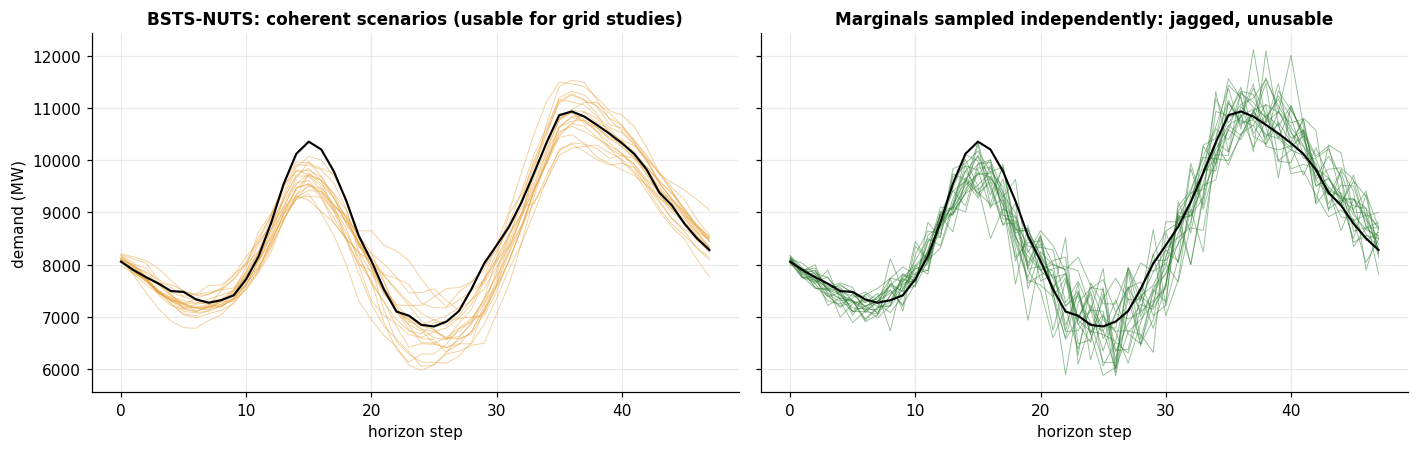

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), sharey=True)
gen = examples["high-demand day"]
for s in range(20):
    axes[0].plot(idx, paths[s, gen, :], color=BSTS_C, lw=0.6, alpha=0.5)
    axes[1].plot(idx, shuffled[s, gen, :], color=LG_GREEN, lw=0.6, alpha=0.5)
axes[0].set_title("BSTS-NUTS: coherent scenarios (usable for grid studies)")
axes[1].set_title("Marginals sampled independently: jagged, unusable")
for ax in axes:
    ax.plot(idx, y[gen], color="black", lw=1.4)
    ax.set_xlabel("horizon step")
axes[0].set_ylabel("demand (MW)")
fig.tight_layout()
save_figure(fig, "bench_generative_scenarios", cfg.paths.figures)
plt.show()

*Takeaway: only the coherent draws are physically plausible days, which is exactly what a downstream grid study can consume.*

**A decision that needs the joint law: the day's total energy.** A procurement
or reserve decision over a whole day depends on the sum of all 48 steps, and
the spread of that sum is driven by the correlation between steps. Coherent
paths give it directly. Marginal quantiles support only an independence
assumption, adding the per-step variances, which ignores the strong positive
correlation of a smooth demand curve and badly understates the risk. The
intra-day ramp is starker still: a step-to-step change is a function of the
joint law of two steps, so marginals cannot give its distribution at all.

daily total (sum of 48 half hours), spread over 108 test days:
  coherent sd:              12674 MW
  marginal-independence sd: 2839 MW
  the independence assumption understates the spread 4.5-fold
  intra-day ramp, coherent P95: 833 MW per half hour (marginals cannot give this)


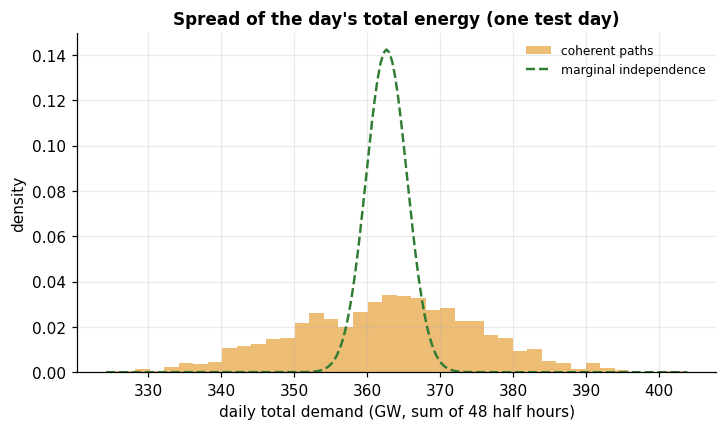

In [11]:
from scipy.stats import norm

total = paths.sum(axis=2)  # (S, O): the day's total per coherent draw
coherent_sd = total.std(axis=0)
independence_sd = np.sqrt(paths.var(axis=0).sum(axis=1))  # all that marginals allow
ramp_p95 = np.quantile(np.abs(np.diff(paths, axis=2)).max(axis=2), 0.95, axis=0)
print(f"daily total (sum of 48 half hours), spread over {n_origins} test days:")
print(f"  coherent sd:              {coherent_sd.mean():.0f} MW")
print(f"  marginal-independence sd: {independence_sd.mean():.0f} MW")
print(
    "  the independence assumption understates the spread "
    f"{coherent_sd.mean() / independence_sd.mean():.1f}-fold"
)
print(
    f"  intra-day ramp, coherent P95: {ramp_p95.mean():.0f} MW per half hour "
    "(marginals cannot give this)"
)

mean_total = paths[:, typical, :].mean(axis=0).sum()
grid = np.linspace(total[:, typical].min(), total[:, typical].max(), 200)
fig, ax = plt.subplots(figsize=(7.5, 4))
ax.hist(
    total[:, typical] / 1000, bins=40, color=BSTS_C, alpha=0.7, density=True, label="coherent paths"
)
ax.plot(
    grid / 1000,
    norm.pdf(grid, mean_total, independence_sd[typical]) * 1000,
    color=LG_GREEN,
    lw=1.6,
    ls="--",
    label="marginal independence",
)
ax.set_xlabel("daily total demand (GW, sum of 48 half hours)")
ax.set_ylabel("density")
ax.set_title("Spread of the day's total energy (one test day)")
ax.legend(fontsize=8)
save_figure(fig, "bench_daily_total", cfg.paths.figures)
plt.show()

*Takeaway: the independence assumption understates the daily-total spread several-fold, so a marginal forecast badly misprices whole-day risk.*

**A grid-stress functional only coherent scenarios can characterise.** Count,
for each scenario, the half hours above a high-load threshold (the 90th
percentile of demand), a proxy for how long the system sits under stress in a
day. Sampling the same marginals independently preserves the expected count but
not its distribution: under independence the exceedances scatter through the
day, whereas in reality they cluster in the evening. An adequacy or reserve
study run on the independent samples would see the right average and badly wrong
tails.

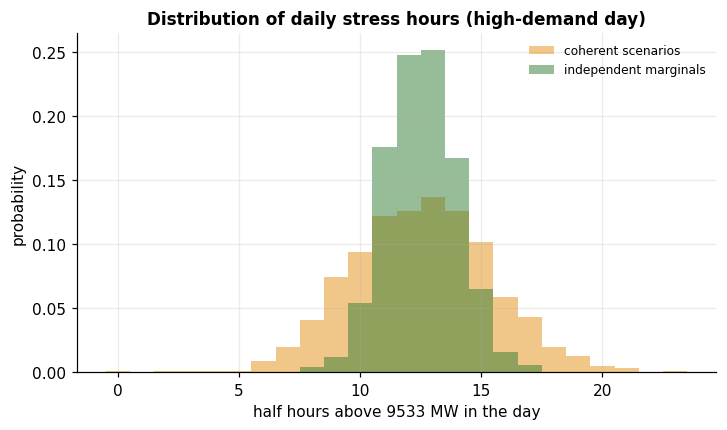

stress hours: coherent mean 12.5 sd 2.9; independent mean 12.5 sd 1.5
Same mean, different spread: the clustering that makes a stress event an event is exactly what the marginal representation throws away.


In [12]:
stress_threshold = np.quantile(y, 0.90)
coherent_stress = (paths[:, gen, :] > stress_threshold).sum(axis=1)
independent_stress = (shuffled[:, gen, :] > stress_threshold).sum(axis=1)
fig, ax = plt.subplots(figsize=(7.5, 4))
bins = np.arange(0, max(coherent_stress.max(), independent_stress.max()) + 2) - 0.5
ax.hist(coherent_stress, bins=bins, color=BSTS_C, alpha=0.6, density=True, label="coherent scenarios")
ax.hist(
    independent_stress, bins=bins, color=LG_GREEN, alpha=0.5, density=True, label="independent marginals"
)
ax.set_xlabel(f"half hours above {stress_threshold:.0f} MW in the day")
ax.set_ylabel("probability")
ax.set_title("Distribution of daily stress hours (high-demand day)")
ax.legend(fontsize=8)
save_figure(fig, "bench_stress_hours", cfg.paths.figures)
plt.show()
print(
    f"stress hours: coherent mean {coherent_stress.mean():.1f} sd {coherent_stress.std():.1f}; "
    f"independent mean {independent_stress.mean():.1f} sd {independent_stress.std():.1f}"
)
print(
    "Same mean, different spread: the clustering that makes a stress event "
    "an event is exactly what the marginal representation throws away."
)

*Takeaway: coherent and independent scenarios share the mean stress duration but not its spread, so only the coherent one gets the tail of a stress event right.*

### 3. A full predictive density

The BSTS posterior predictive is a density at every step, so the CDF, any tail
probability and a log score are all defined everywhere. LightGBM returns
fifteen quantiles; between them a density has to be interpolated, and beyond the
outer pair it simply is not there. The three steps below are picked by where the
two models most part on per-step CRPS across the test set, one the BSTS wins, one
they draw and one LightGBM wins, shown here for the median-demand day: a smooth
BSTS density against fifteen LightGBM points.

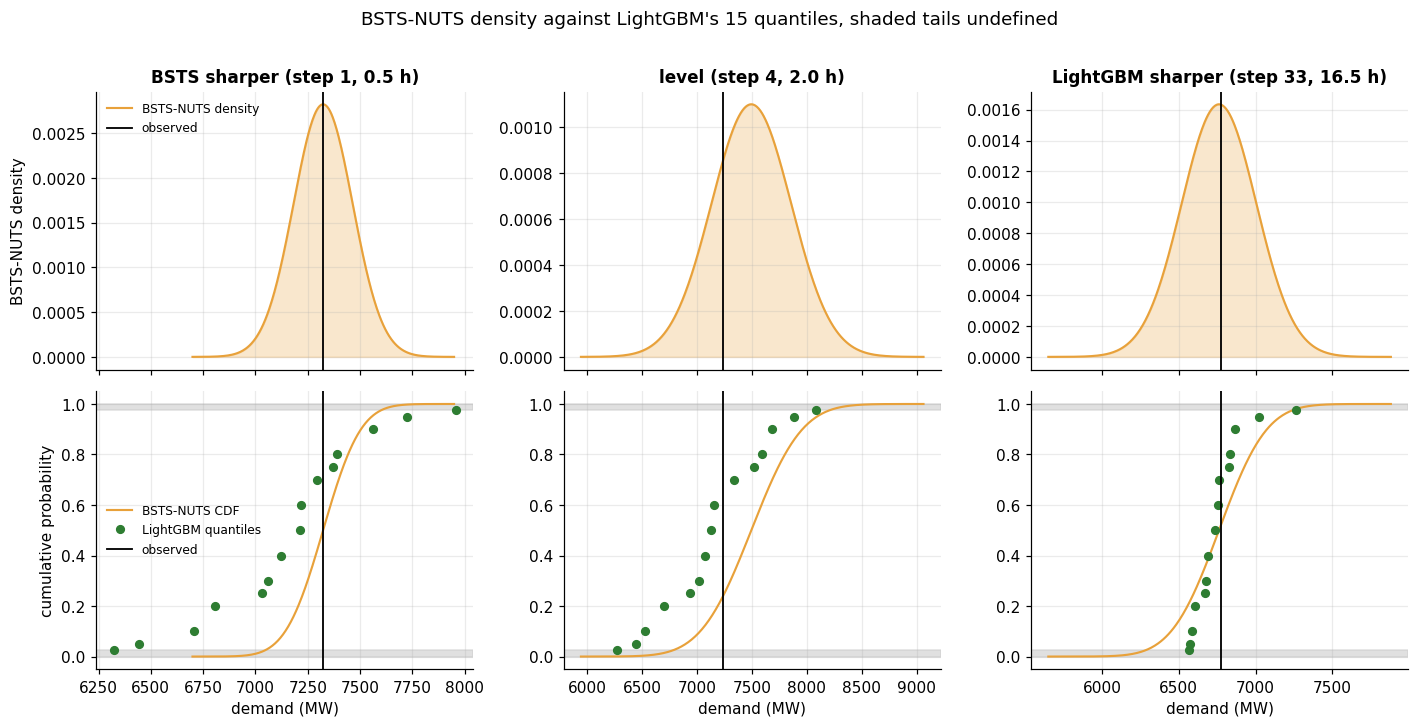

In [13]:
i = examples["median-demand day"]
# Pick the steps by where the two models most part on per-step CRPS across the
# test set: one the BSTS wins, one they draw, one LightGBM wins.
crps_gap = lg_h - bayes_h  # positive where the BSTS is the sharper of the two
chosen_steps = {
    "BSTS sharper": int(np.argmax(crps_gap)),
    "level": int(np.argmin(np.abs(crps_gap))),
    "LightGBM sharper": int(np.argmin(crps_gap)),
}
step_labels = {f"{name} (step {h + 1}, {(h + 1) / 2:.1f} h)": h for name, h in chosen_steps.items()}
fig, axes = plt.subplots(2, len(step_labels), figsize=(13, 6.5), sharex="col")
for col, (label, h) in enumerate(step_labels.items()):
    dm, ds = bsts_mean[:, i, h], bsts_sd[:, i, h]
    grid = np.linspace(dm.min() - 4 * ds.max(), dm.max() + 4 * ds.max(), 400)
    density = averaged_gaussian_pdf(grid, dm[:, None], ds[:, None])[0]  # Rao-Blackwellised mixture
    cdf = averaged_gaussian_cdf(grid, dm[:, None], ds[:, None])[0]
    axes[0, col].fill_between(grid, density, color=BSTS_C, alpha=0.25)
    axes[0, col].plot(grid, density, color=BSTS_C, lw=1.4, label="BSTS-NUTS density")
    axes[0, col].axvline(y[i, h], color="black", lw=1.2, label="observed")
    axes[0, col].set_title(label)
    axes[1, col].plot(grid, cdf, color=BSTS_C, lw=1.4, label="BSTS-NUTS CDF")
    axes[1, col].plot(quantiles[i, :, h], levels, "o", color=LG_GREEN, ms=5, label="LightGBM quantiles")
    axes[1, col].axvline(y[i, h], color="black", lw=1.2, label="observed")
    axes[1, col].axhspan(0.975, 1.0, color="#cccccc", alpha=0.6)
    axes[1, col].axhspan(0.0, 0.025, color="#cccccc", alpha=0.6)
    axes[1, col].set_xlabel("demand (MW)")
axes[0, 0].set_ylabel("BSTS-NUTS density")
axes[1, 0].set_ylabel("cumulative probability")
axes[0, 0].legend(fontsize=8)
axes[1, 0].legend(fontsize=8)
fig.suptitle("BSTS-NUTS density against LightGBM's 15 quantiles, shaded tails undefined", y=1.01)
fig.tight_layout()
save_figure(fig, "bench_density_vs_quantiles", cfg.paths.figures)
plt.show()

*Takeaway: the BSTS gives a full density and CDF at every step; LightGBM gives fifteen points, with the tails beyond them undefined.*

In [14]:
threshold = np.quantile(y, 0.97)
bayes_exceed = (paths > threshold).mean(axis=0)
top_q = quantiles[:, levels.tolist().index(0.975), :]
beyond = 100 * (top_q < threshold).mean()
print(f"threshold (97th percentile of demand): {threshold:.0f} MW")
print(f"BSTS-NUTS: exact P(exceed) everywhere; mean {bayes_exceed.mean():.3f}, max {bayes_exceed.max():.2f}")
print(f"LightGBM: threshold is beyond its 97.5 quantile in {beyond:.0f}% of cells,")
print("          where it can say no more than 'below 2.5%'")
print(
    "BSTS-NUTS log score (density-based, Rao-Blackwellised): "
    f"{np.mean([rb_log_score(y[i], bsts_mean[:, i, :], bsts_sd[:, i, :]).mean() for i in range(n_origins)]):.2f}; "
    "LightGBM log score: undefined"
)

threshold (97th percentile of demand): 10733 MW
BSTS-NUTS: exact P(exceed) everywhere; mean 0.019, max 0.93
LightGBM: threshold is beyond its 97.5 quantile in 95% of cells,
          where it can say no more than 'below 2.5%'
BSTS-NUTS log score (density-based, Rao-Blackwellised): 7.38; LightGBM log score: undefined


*Takeaway: the BSTS gives an exact exceedance probability for any threshold, where LightGBM can only say a rare level sits beyond its outermost quantile.*

### 4. Decomposed, interpretable uncertainty

The BSTS predictive variance splits exactly into a *parameter* (epistemic) part
that more data would shrink and an *alea* (aleatoric) part that is irreducible
under the model. The alea is the chance term (Latin for a die): the accumulated
innovation noise, the one-step-ahead surprises the model could not predict,
building up over the horizon at the heteroskedastic scale sigma_t. Because the
epistemic part is small and shrinks as the horizon grows, the figure plots its
share alone on a log axis; whatever is left up to one is the alea. LightGBM
returns calibrated quantiles with no such split and no generative structure to
read.

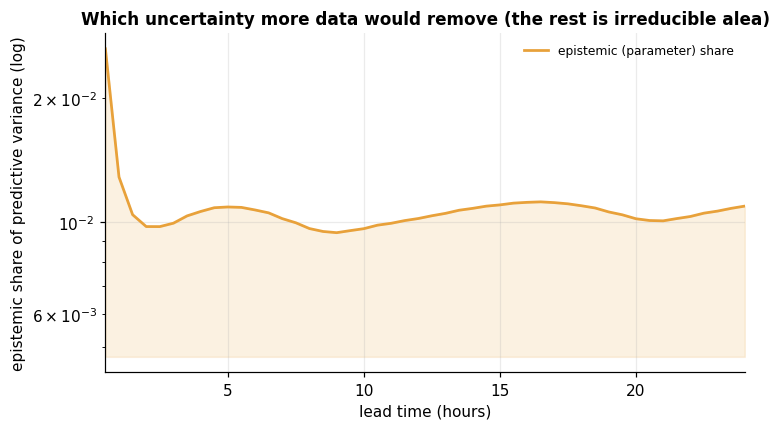

epistemic share over the horizon: 1.1% - with two years of training the parameters are pinned down, so almost all
predictive uncertainty is irreducible. LightGBM cannot make that statement.


In [15]:
panel = load_panel(cfg.paths.processed)
splits = load_splits(cfg.paths.processed)
max_lag = max(cfg.features.demand_lags)
fit_index = splits["train"].index[max_lag:]
inputs = bsts.prepare_inputs(panel, cfg, fit_index)
test_origins = rolling_origins(splits["test"].index, panel.index, cfg.origins, cfg.horizon, max_lag)
parts = variance_decomposition_innovations(nuts_draws, inputs, panel, cfg, test_origins)
total_var = parts["parameter"] + parts["innovation"]
epistemic = (parts["parameter"] / total_var).mean(axis=0)

fig, ax = plt.subplots(figsize=(7.5, 4))
ax.plot(hours, epistemic, color=BSTS_C, lw=1.8, label="epistemic (parameter) share")
ax.fill_between(hours, epistemic.min() / 2, epistemic, color=BSTS_C, alpha=0.15)
ax.set_yscale("log")  # the epistemic share is tiny and shrinks with lead, so a log axis keeps it legible
ax.set_xlabel("lead time (hours)")
ax.set_ylabel("epistemic share of predictive variance (log)")
ax.set_xlim(hours[0], hours[-1])
ax.set_title("Which uncertainty more data would remove (the rest is irreducible alea)")
ax.legend(loc="upper right", fontsize=8)
save_figure(fig, "bench_aleatoric_epistemic", cfg.paths.figures)
plt.show()
print(
    f"epistemic share over the horizon: {(parts['parameter'] / total_var).mean():.1%} "
    "- with two years of training the parameters are pinned down, so almost all"
)
print("predictive uncertainty is irreducible. LightGBM cannot make that statement.")

*Takeaway: almost all the predictive variance is the irreducible alea term, so more data would barely narrow these bands, a statement LightGBM cannot make at all.*

### 5. Forecast from any origin, out to any horizon

The BSTS (NUTS reference) is fitted on the contiguous demand series, not on
stacked forecast blocks, so it defines a forecast from any half-hourly origin
and for any horizon. The two daily origins and the 48-step window are the
evaluation protocol, not a limit of the model, and LightGBM has neither
freedom.

**Any start time.** LightGBM is trained on origin blocks issued at 00:00 and
12:00, which ties lead time to time of day in its rows, so a forecast issued at,
say, 07:00 asks for lead-and-time-of-day pairs it never saw. Covering all 48
half-hourly origins would mean roughly 24 times the training blocks and a
diluted recency signal. The BSTS just conditions on the residual at whatever
origin it is handed. Below it forecasts the same day from four start times.

**Any horizon.** Past 24 hours the one-day demand lag points inside the
forecast window, so the model is rolled forward: each day's central forecast
fills the lag for the next. The three-day forecast below does exactly that.
LightGBM cannot be rolled this way, because its heads are fixed to the 48 steps
they were trained for, marked by the line at step 48.

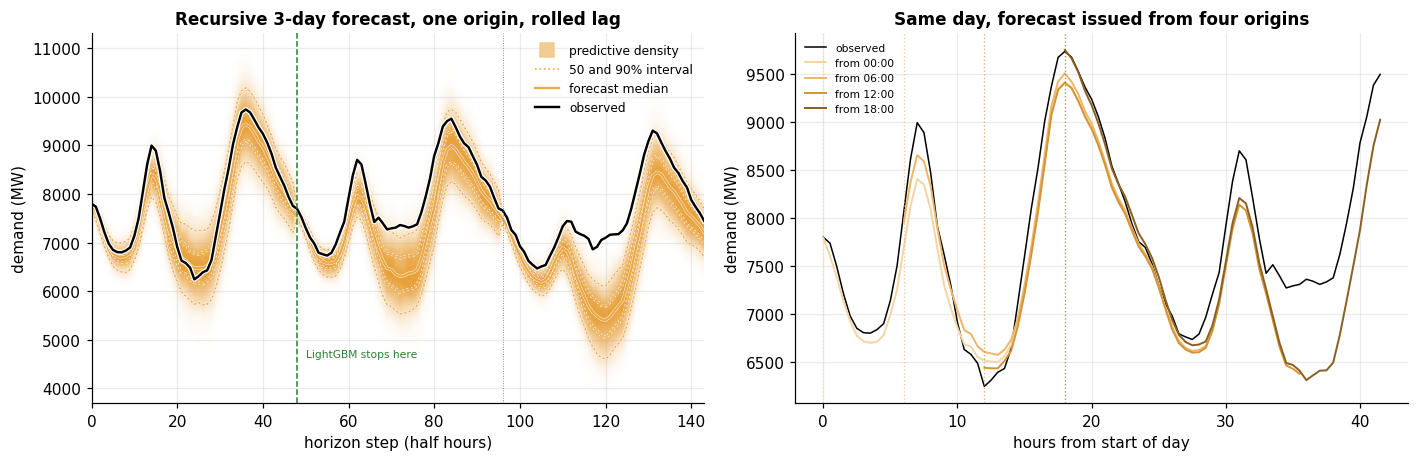

recursive 3-day forecast MAE vs observed: 495 MW
plug-in roll: each day's lag uses the previous day's central forecast, so the bands reflect within-horizon noise given that path and understate compounding across days


In [16]:
rec_draws = nuts_draws


def bayes_forecast(frame, origin, steps, seed):
    """Predictive paths (S, steps) in MW from any origin, using ``frame``'s
    demand for the lags, so a rolled-forward frame gives a recursive forecast."""
    hist = frame.index[
        (frame.index >= inputs.index[0]) & (frame.index <= origin + pd.Timedelta(minutes=30 * steps))
    ]
    design = build_design(frame, cfg, "actual").loc[hist]
    vdesign = variance_design(frame, cfg, "actual").loc[hist]
    x_hist, _ = bsts.transform_design(inputs, design, vdesign)
    y_hist = ((frame["demand_mw"].loc[hist].to_numpy() - inputs.y_loc) / inputs.y_scale).astype(
        np.float32
    )
    e0 = innovations.origin_residuals(rec_draws, y_hist, x_hist, hist.get_indexer([origin]))
    target = horizon_index(origin, steps)
    xf, zf = bsts.transform_design(inputs, design.loc[target], vdesign.loc[target])
    sim = innovations.simulate_horizon_paths(rec_draws, e0, xf[None], zf[None], cfg.bsts, seed=seed)
    return np.asarray(sim[:, 0, :]) * inputs.y_scale + inputs.y_loc


base = pd.Timestamp("2026-05-20 14:00", tz="UTC")  # 21 May 2026, 00:00 AEST
window = panel.loc[base - pd.Timedelta(days=12) : base + pd.Timedelta(days=4)].copy()
n_days = 3

# Recursive multi-day: roll each day's central forecast into the one-day lag.
roll, segments, cur = window.copy(), [], base
for d in range(n_days):
    seg = bayes_forecast(roll, cur, horizon, seed=cfg.seed + d)
    segments.append(seg)
    roll.loc[horizon_index(cur, horizon), "demand_mw"] = seg.mean(axis=0)
    cur = cur + pd.Timedelta(hours=24)
multi = np.concatenate(segments, axis=1)  # (S, 48 * n_days)
multi_obs = panel["demand_mw"].loc[horizon_index(base, n_days * horizon)].to_numpy()
multi_steps = np.arange(n_days * horizon)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.3))
density_ribbon(
    axes[0],
    multi_steps,
    samples=multi,
    observed=multi_obs,
    cmap=BSTS_CMAP,
    label="forecast median",
)
axes[0].axvline(horizon, color=LG_GREEN, ls="--", lw=1.0)
axes[0].axvline(2 * horizon, color="grey", ls=":", lw=0.6)
axes[0].text(
    horizon + 2,
    np.quantile(multi, 0.05, 0).min(),
    "LightGBM stops here",
    fontsize=7,
    color=LG_GREEN,
    va="bottom",
)
axes[0].set_title(f"Recursive {n_days}-day forecast, one origin, rolled lag")
axes[0].set_xlabel("horizon step (half hours)")
axes[0].set_ylabel("demand (MW)")
axes[0].legend(fontsize=8)

span = horizon_index(base, 18 * 2 + horizon)
span_hours = (span - base).total_seconds() / 3600
axes[1].plot(span_hours, panel["demand_mw"].loc[span].to_numpy(), color="black", lw=1.0, label="observed")
for colour, h in zip(model_shades("BSTS-NUTS", 4), (0, 6, 12, 18), strict=True):
    issue = base + pd.Timedelta(hours=h)
    fc = bayes_forecast(window, issue, horizon, seed=cfg.seed + 100 + h)
    axes[1].axvline(h, color=colour, ls=":", lw=0.9, alpha=0.7)  # mark when this forecast is issued
    axes[1].plot(
        h + idx * 0.5,
        np.median(fc, 0),
        color=colour,
        lw=1.3,
        label=f"from {issue.tz_convert('Australia/Brisbane').strftime('%H:%M')}",
    )
axes[1].set_title("Same day, forecast issued from four origins")
axes[1].set_xlabel("hours from start of day")
axes[1].set_ylabel("demand (MW)")
axes[1].legend(fontsize=7)
fig.tight_layout()
save_figure(fig, "bench_any_origin_horizon", cfg.paths.figures)
plt.show()
print(
    f"recursive {n_days}-day forecast MAE vs observed: "
    f"{np.abs(np.median(multi, 0) - multi_obs).mean():.0f} MW"
)
print(
    "plug-in roll: each day's lag uses the previous day's central forecast, so the bands reflect "
    "within-horizon noise given that path and understate compounding across days"
)

*Takeaway: the BSTS forecasts from any origin and rolls past 24 hours; LightGBM stops at the 48 steps its heads were trained for.*

## Calibration: the BSTS is the honest one

A richer output would matter little if it were less honest, so this is the
decisive panel. The PIT histograms and central coverage show the BSTS close to
nominal, while LightGBM is overconfident: its independently fitted quantile
heads run too narrow, so its intervals cover less than they claim. That is the
hidden cost behind LightGBM's lower CRPS: a sharper single number bought with
intervals you cannot trust. The BSTS buys its richer output at no calibration
cost.

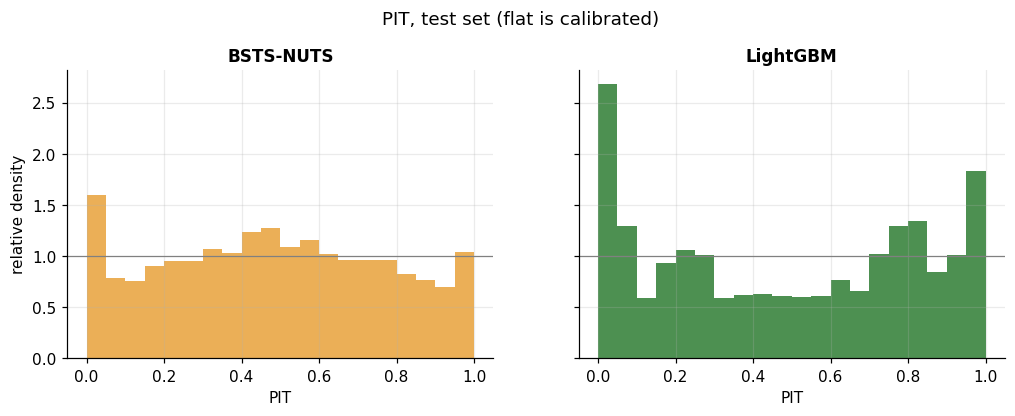

In [17]:
bayes_pit = np.concatenate(
    [rb_pit(y[i], bsts_mean[:, i, :], bsts_sd[:, i, :]) for i in range(n_origins)]
)
lg_pit = np.array(
    [
        np.interp(y[i, j], quantiles[i, :, j], levels, left=0.0, right=1.0)
        for i in range(n_origins)
        for j in range(horizon)
    ]
)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4), sharey=True)
for ax, pit, name, colour in (
    (axes[0], bayes_pit, "BSTS-NUTS", BSTS_C),
    (axes[1], lg_pit, "LightGBM", LG_GREEN),
):
    density, edges = pit_histogram(pit, bins=20)
    ax.bar(edges[:-1], density, width=np.diff(edges), align="edge", color=colour, alpha=0.85)
    ax.axhline(1.0, color="grey", lw=0.8)
    ax.set_title(name)
    ax.set_xlabel("PIT")
axes[0].set_ylabel("relative density")
fig.suptitle("PIT, test set (flat is calibrated)", y=1.04)
save_figure(fig, "bench_pit", cfg.paths.figures)
plt.show()

The empirical-CDF view sharpens the same comparison: the PIT ECDF minus the
uniform line, with the simultaneous 95 percent band (the Kolmogorov-Smirnov
envelope for this many points, which assumes independent PIT values and so reads
tight, since ours are correlated within a day). The BSTS hugs the band closely;
LightGBM swings far outside it, the over-confidence made unambiguous.

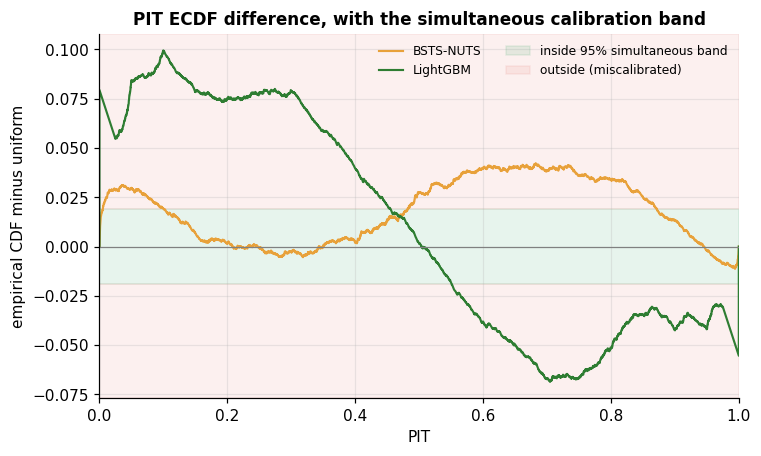

In [18]:
ks_band = ecdf_uniform_band(bayes_pit.size)
fig, ax = plt.subplots(figsize=(7.5, 4.3))
for pit, name, colour in ((bayes_pit, "BSTS-NUTS", BSTS_C), (lg_pit, "LightGBM", LG_GREEN)):
    grid, diff = pit_ecdf_difference(pit)
    ax.plot(grid, diff, color=colour, lw=1.4, label=name)
ax.axhline(0.0, color="grey", lw=0.8)
# green inside the simultaneous band (calibrated), red outside (miscalibrated)
pass_fail_hband(ax, ks_band)
ax.set_xlim(0, 1)
ax.set_xlabel("PIT")
ax.set_ylabel("empirical CDF minus uniform")
ax.set_title("PIT ECDF difference, with the simultaneous calibration band")
ax.legend(fontsize=8, ncol=2)
save_figure(fig, "bench_pit_ecdf", cfg.paths.figures)
plt.show()

*Takeaway: the BSTS curve hugs the band, poking only marginally outside it, while LightGBM's runs far into the red, the over-confidence its histogram only hinted at, now an unambiguous failure of the simultaneous test.*


def coverage(get_interval) -> dict:
    out = {}
    for level in cfg.evaluation.interval_levels:
        lo, hi = get_interval(level)
        out[f"cover {level:.0%}"] = float(((y >= lo) & (y <= hi)).mean())
    return out


bayes_cov = coverage(
    lambda L: (np.quantile(paths, 0.5 - L / 2, axis=0), np.quantile(paths, 0.5 + L / 2, axis=0))
)
lg_cov = coverage(
    lambda L: (
        quantiles[:, levels.tolist().index(round(0.5 - L / 2, 3)), :],
        quantiles[:, levels.tolist().index(round(0.5 + L / 2, 3)), :],
    )
)
pd.DataFrame({"BSTS-NUTS": bayes_cov, "LightGBM": lg_cov}).round(2)

*Takeaway: the BSTS PIT is near flat and its coverage near nominal; LightGBM piles mass in the tails and under-covers, the calibration cost behind its lower CRPS.*

The same coverage as a curve, swept across nominal level, with the green corridor
the simultaneous tolerance around the diagonal. Above the diagonal the bands are
too wide, below it too narrow.

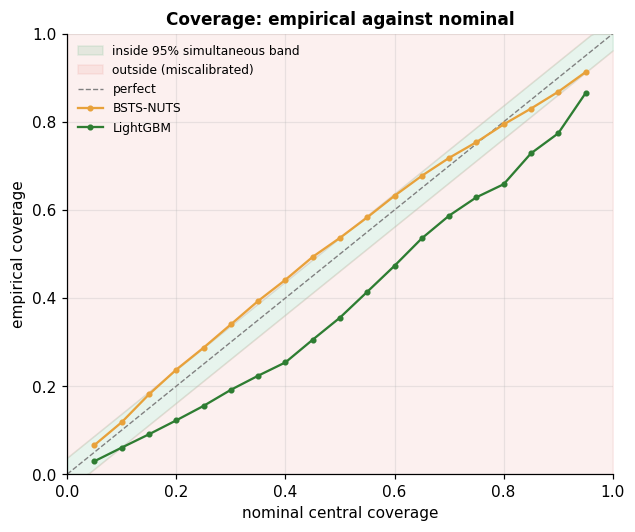

In [19]:
sweep = np.linspace(0.05, 0.95, 19)


def coverage_curve(pit: np.ndarray) -> np.ndarray:
    """Empirical central-interval coverage at each nominal level, from the PIT."""
    return np.array([np.mean(np.abs(pit - 0.5) <= q / 2) for q in sweep])


fig, ax = plt.subplots(figsize=(6.4, 5.2))
pass_fail_diagonal(ax, 2 * ecdf_uniform_band(bayes_pit.size))
ax.plot([0, 1], [0, 1], color="grey", ls="--", lw=0.9, label="perfect")
for pit, name, colour in ((bayes_pit, "BSTS-NUTS", BSTS_C), (lg_pit, "LightGBM", LG_GREEN)):
    ax.plot(sweep, coverage_curve(pit), marker="o", ms=3, color=colour, label=name)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel("nominal central coverage")
ax.set_ylabel("empirical coverage")
ax.set_title("Coverage: empirical against nominal")
ax.legend(fontsize=8, loc="upper left")
save_figure(fig, "bench_coverage_curve", cfg.paths.figures)
plt.show()

*Takeaway: the BSTS coverage curve sits on the diagonal inside the green corridor, while LightGBM runs below it at every level, its over-confidence read in coverage terms.*

## Summary: when to use which

- **LightGBM** for the single sharpest point or quantile, especially beyond a
  couple of hours, and for an operationally simple model with no inference to
  monitor and no hand-built interactions. It is the better choice when the
  deliverable is a number and robustness matters more than structure, as long
  as you can live with intervals that run a little overconfident.
- **BSTS** when the near horizon matters most, when decisions span the whole day
  and need coherent scenarios (the energy total, the intra-day ramp, anything
  path-dependent), when a density or a tail probability is required, or when the
  question is how much of the uncertainty more data could remove.
- And beyond forecasting altogether: only the BSTS is generative, so only it can
  supply the coherent demand scenarios that grid studies, storage and reserve
  sizing and power-flow simulations consume. LightGBM's independence across
  steps rules it out of those uses.
- LightGBM's lower CRPS is paid for in calibration: its intervals run
  overconfident, while the BSTS stays close to nominal. On this hardware the
  BSTS fit is also the faster of the two, so the genuine LightGBM advantages are
  marginal point accuracy and operational simplicity, not speed and not honesty.